# Charge Gate Ramsey — Track & Combine
Scan a data folder for all `charge_gate_ramsey` subfolders, run `ChargeGateRamseyAnalyzer` on each,
and combine the `|cos|` fit parameters into a single `xarray.Dataset` indexed by `run_start` time.

In [1]:
import json
import datetime
from pathlib import Path
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.protocols.charge_gate_ramsey import ChargeGateRamseyAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data, parse_timestamp

## 1. Configuration

In [2]:
# Root folder containing sub-folders like #1049_LCH_charge_gate_ramsey_0_221013/
DATA_ROOT = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR_test"

# Pattern to match charge-gate-ramsey subfolders
FOLDER_PATTERN = "*charge_gate_ramsey*"

# Variable name in the raw dataset to use as the signal
SIGNAL_VAR = "I"

# Output HDF5 path for the combined results
Ramsey_OUTPUT_H5 = str(Path(DATA_ROOT) / "charge_gate_ramsey_combined.h5")
RO_OUTPUT_H5 = str(Path(DATA_ROOT) / "ro_charge_power_combined.h5")

FIGURE_SAVE_PATH   = os.path.join(DATA_ROOT, "figures")   # e.g. r"output/state_disc"
# Create figures directory under the same folder as H5_PATH
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

# Optional analysis kwargs forwarded to ChargeGateRamseyAnalyzer
ANALYSIS_KWARGS = {
    # "force_model": "beat",
    "f_c_fixed": 0.0002,
    # "abscos_frequency_fixed": 0.54,
    "abscos_frequency_fixed": 0.59, #Q2
    "abscos_phase_bounds": (-0.5, 0.5),  # (min, max) bounds for |cos| phase parameter
}

## 2. Discover Subfolders

In [3]:
root = Path(DATA_ROOT)
subfolders = sorted(root.glob(FOLDER_PATTERN))
# Keep only directories that contain both ds_raw.h5 and node.json
subfolders = [d for d in subfolders if d.is_dir() and (d / "ds_raw.h5").exists() and (d / "node.json").exists()]
print(f"Found {len(subfolders)} charge_gate_ramsey folders:")
# for sf in subfolders:
#     print(f"  {sf.name}")

Found 30 charge_gate_ramsey folders:


## 3. Run Analysis Loop

In [4]:
analyzer = ChargeGateRamseyAnalyzer()

records = []  # list of dicts, one per successful run

for sf in subfolders:
    h5_path = sf / "ds_raw.h5"
    node_path = sf / "node.json"

    # --- Parse timestamps from node.json ---
    with open(node_path, "r", encoding="utf-8") as f:
        node = json.load(f)
    run_start_str = node["metadata"]["run_start"]
    run_end_str = node["metadata"]["run_end"]
    run_start = parse_timestamp(run_start_str)
    run_end = parse_timestamp(run_end_str)
    exp_time = (run_end - run_start).total_seconds()

    # --- Load and prepare dataset ---
    try:
        dataset = load_xarray_h5(str(h5_path))
        sq_data = repetition_data(dataset)[0]
        if SIGNAL_VAR != "signal" and SIGNAL_VAR in sq_data:
            sq_data = sq_data.rename({SIGNAL_VAR: "signal"})
    except Exception as e:
        print(f"  [SKIP] {sf.name}: failed to load data — {e}")
        continue

    # --- Run analyzer ---
    try:
        results, figs = analyzer.analyze(sq_data, **ANALYSIS_KWARGS)
        for fig in figs.values():
            plt.close(fig)
    except Exception as e:
        print(f"  [SKIP] {sf.name}: analysis failed — {e}")
        continue

    # --- Collect record ---
    abscos = results.get("abscos_params") or {}
    record = {
        "run_start": np.datetime64(run_start),
        "folder": sf.name,
        "exp_time": exp_time,
        "f_c": results["f_c"],
        "abscos_amplitude": abscos.get("amplitude", np.nan),
        "abscos_frequency": abscos.get("frequency", np.nan),
        "abscos_phase": abscos.get("phase", np.nan),
        "abscos_redchi": abscos.get("redchi", np.nan),
        "abscos_success": abscos.get("success", False),
    }
    records.append(record)
    status = "OK" if record["abscos_success"] else "NO FIT"
    # print(f"  [{status}] {sf.name}  run_start={run_start}  exp_time={exp_time:.1f}s")

print(f"\nCompleted: {len(records)} / {len(subfolders)} runs")


Completed: 30 / 30 runs


## 4. Build Combined Dataset

In [5]:
if len(records) == 0:
    raise RuntimeError("No successful runs to combine.")

run_starts = np.array([r["run_start"] for r in records])

combined_ds = xr.Dataset(
    {
        "exp_time":          ("run_start", [r["exp_time"]          for r in records]),
        "f_c":               ("run_start", [r["f_c"]               for r in records]),
        "abscos_amplitude":  ("run_start", [r["abscos_amplitude"]  for r in records]),
        "abscos_frequency":  ("run_start", [r["abscos_frequency"]  for r in records]),
        "abscos_phase":      ("run_start", [r["abscos_phase"]      for r in records]),
        "abscos_redchi":     ("run_start", [r["abscos_redchi"]     for r in records]),
        "abscos_success":    ("run_start", [r["abscos_success"]    for r in records]),
    },
    coords={
        "run_start": run_starts,
        "folder":    ("run_start", [r["folder"] for r in records]),
    },
)
combined_ds

<xarray.Dataset> Size: 6kB
Dimensions:           (run_start: 30)
Coordinates:
  * run_start         (run_start) datetime64[us] 240B 2026-04-14T10:38:42.620...
    folder            (run_start) <U38 5kB '#1605_LCH_charge_gate_ramsey_0_10...
Data variables:
    exp_time          (run_start) float64 240B 9.607 9.047 9.221 ... 8.52 8.558
    f_c               (run_start) float64 240B 0.0002 0.0002 ... 0.0002 0.0002
    abscos_amplitude  (run_start) float64 240B 9.866e-05 9.873e-05 ... 9.931e-05
    abscos_frequency  (run_start) float64 240B 0.59 0.59 0.59 ... 0.59 0.59 0.59
    abscos_phase      (run_start) float64 240B -0.4933 0.3551 ... -0.2713
    abscos_redchi     (run_start) float64 240B 9.987e-12 2.16e-11 ... 3.214e-11
    abscos_success    (run_start) bool 30B True True True ... True True True

## 5. Save to HDF5

In [6]:
combined_ds.to_netcdf(Ramsey_OUTPUT_H5, engine="h5netcdf")
print(f"Saved combined results to:\n  {Ramsey_OUTPUT_H5}")

Saved combined results to:
  D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR_test\charge_gate_ramsey_combined.h5


## 6. Quick Plots

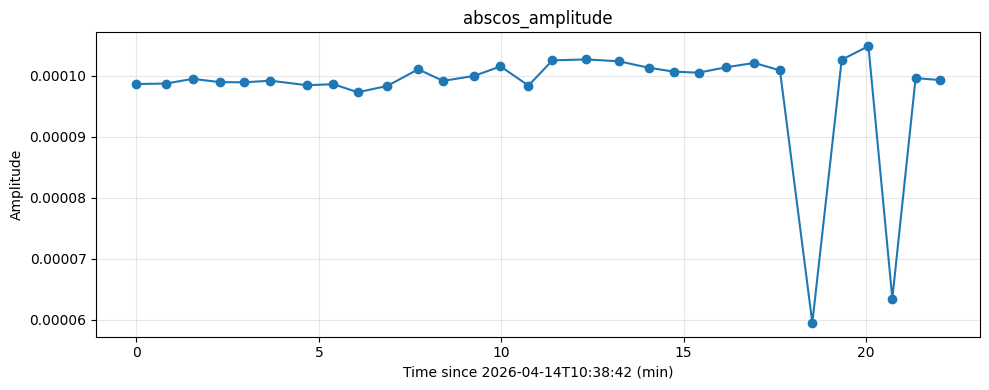

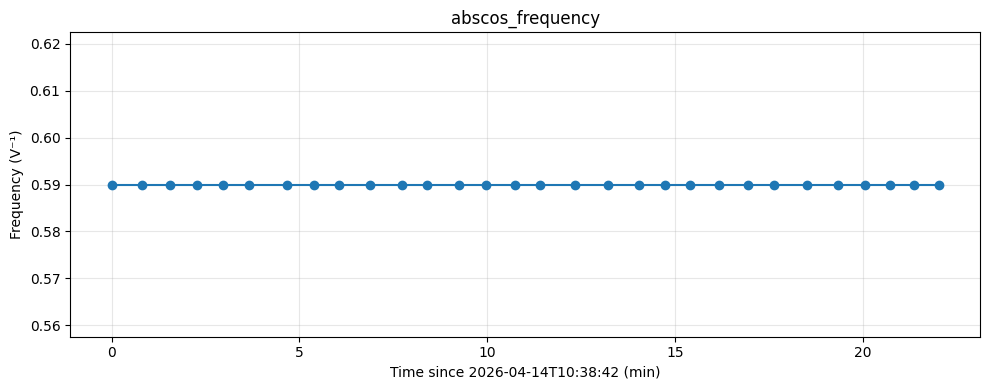

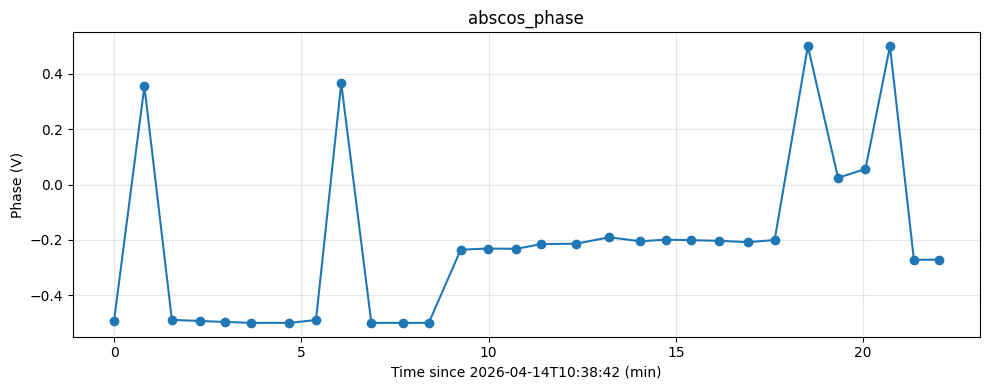

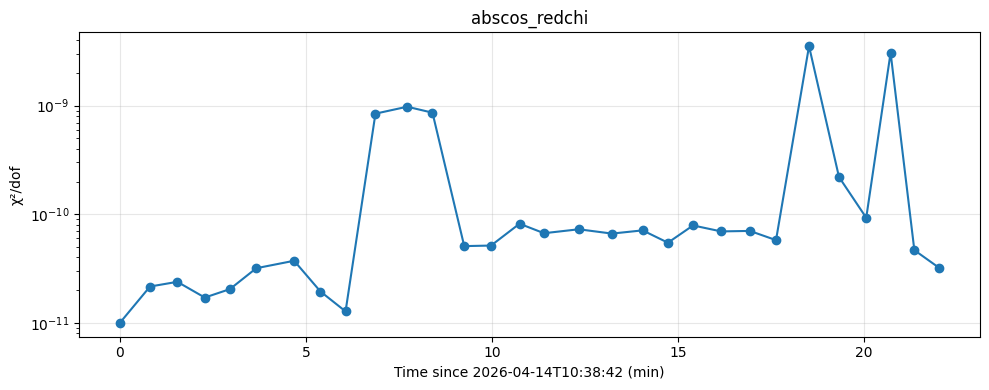

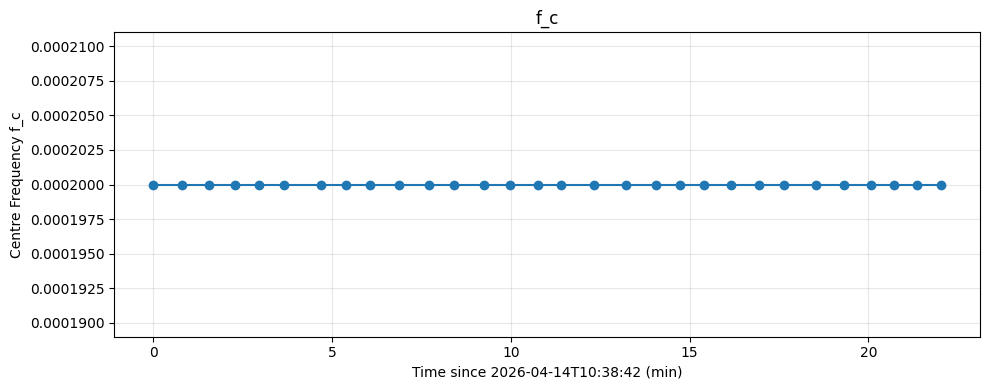

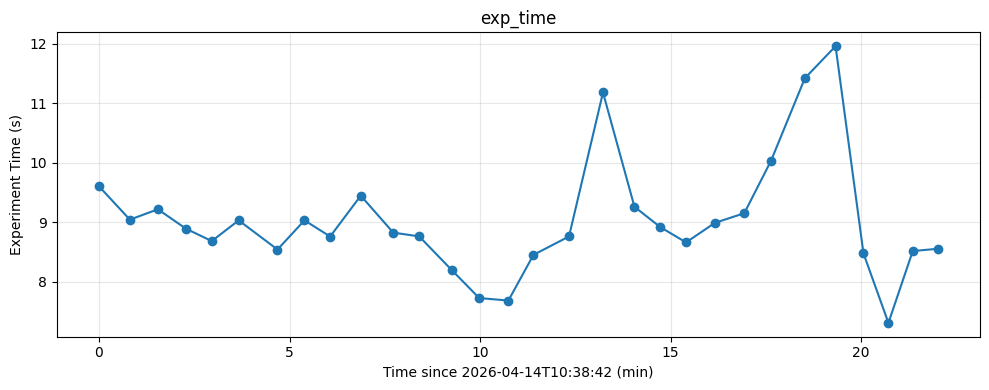

In [7]:
t_abs = combined_ds.coords["run_start"].values
t_rel = (t_abs - t_abs[0]) / np.timedelta64(1, "m")  # relative time in minutes

params = {
    "abscos_amplitude": ("Amplitude", None),
    "abscos_frequency": ("Frequency (V⁻¹)", None),
    "abscos_phase":     ("Phase (V)", None),
    "abscos_redchi":    ("χ²/dof", "log"),
    "f_c":              ("Centre Frequency f_c", None),
    "exp_time":         ("Experiment Time (s)", None),
}

for var, (ylabel, yscale) in params.items():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_rel, combined_ds[var].values, "o-")
    ax.set_ylabel(ylabel)
    ax.set_xlabel(f"Time since {str(t_abs[0])[:19]} (min)")
    ax.set_title(var)
    if yscale:
        ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGURE_SAVE_PATH,f"{var}.png"), dpi=150, bbox_inches="tight")
    plt.show()

---
# Readout Power with Reference — Stack & Combine
Scan `DATA_ROOT` for all `charge_gate_readout_power_with_ref` subfolders,
load each `ds_raw.h5`, and stack `I1_1 … I1_3`, `Q1_1 … Q1_3` along a new `run_start` coordinate.

In [8]:
RO_FOLDER_PATTERN = "*charge_gate_readout_power_with_ref*"
RO_SIGNAL_VARS = ["I1_1", "I1_2", "I1_3", "Q1_1", "Q1_2", "Q1_3"]

ro_root = Path(DATA_ROOT)
ro_subfolders = sorted(ro_root.glob(RO_FOLDER_PATTERN))
ro_subfolders = [
    d for d in ro_subfolders
    if d.is_dir() and (d / "ds_raw.h5").exists() and (d / "node.json").exists()
]
print(f"Found {len(ro_subfolders)} readout-power-with-ref folders:")
# for sf in ro_subfolders:
#     print(f"  {sf.name}")

Found 29 readout-power-with-ref folders:


In [9]:
ro_datasets = []
ro_run_starts = []
ro_exp_times = []  # run_end - run_start in seconds

for sf in ro_subfolders:
    h5_path = sf / "ds_raw.h5"
    node_path = sf / "node.json"

    # --- Parse timestamps ---
    with open(node_path, "r", encoding="utf-8") as f:
        node = json.load(f)
    run_start = parse_timestamp(node["metadata"]["run_start"])
    run_end = parse_timestamp(node["metadata"]["run_end"])
    exp_time = (run_end - run_start).total_seconds()

    # --- Load dataset ---
    try:
        dataset = load_xarray_h5(str(h5_path))
        sq_data = repetition_data(dataset)[0]
    except Exception as e:
        print(f"  [SKIP] {sf.name}: {e}")
        continue

    # Keep only the 6 target variables
    missing = [v for v in RO_SIGNAL_VARS if v not in sq_data]
    if missing:
        print(f"  [SKIP] {sf.name}: missing vars {missing}")
        continue

    ro_datasets.append(sq_data[RO_SIGNAL_VARS])
    ro_run_starts.append(np.datetime64(run_start))
    ro_exp_times.append(exp_time)
    # print(f"  [OK] {sf.name}  run_start={run_start}  exp_time={exp_time:.1f}s")

print(f"\nLoaded: {len(ro_datasets)} / {len(ro_subfolders)} runs")


Loaded: 29 / 29 runs


In [10]:
if len(ro_datasets) == 0:
    raise RuntimeError("No readout-power runs loaded.")

# Add run_start as a new coordinate to each dataset, then concatenate
run_start_arr = np.array(ro_run_starts)
for i, ds in enumerate(ro_datasets):
    ro_datasets[i] = ds.expand_dims(run_start=[ro_run_starts[i]])

ro_combined = xr.concat(ro_datasets, dim="run_start")

# Attach exp_time (run_end − run_start) as a variable indexed by run_start
ro_combined["exp_time"] = ("run_start", ro_exp_times)

# Store Ramsey fit parameter as metadata
ro_combined.attrs["abscos_frequency_fixed"] = ANALYSIS_KWARGS["abscos_frequency_fixed"]

print(ro_combined)
ro_combined

<xarray.Dataset> Size: 55MB
Dimensions:         (run_start: 29, prepared_state: 2, charge_gate: 49,
                     amp_prefactor: 20, shot_idx: 20)
Coordinates:
  * run_start       (run_start) datetime64[us] 232B 2026-04-14T10:38:53.13000...
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * shot_idx        (shot_idx) float64 160B 1.0 2.0 3.0 4.0 ... 18.0 19.0 20.0
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           <U2 8B 'q1'
Data variables:
    I1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    I1_2            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    I1_3            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    Q1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    Q1

<xarray.Dataset> Size: 55MB
Dimensions:         (run_start: 29, prepared_state: 2, charge_gate: 49,
                     amp_prefactor: 20, shot_idx: 20)
Coordinates:
  * run_start       (run_start) datetime64[us] 232B 2026-04-14T10:38:53.13000...
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * shot_idx        (shot_idx) float64 160B 1.0 2.0 3.0 4.0 ... 18.0 19.0 20.0
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           <U2 8B 'q1'
Data variables:
    I1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    I1_2            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    I1_3            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    Q1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    Q1_2            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    Q1_3            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 9MB ...
    exp_time        (run_start) float64 232B 38.06 34.08 34.35 ... 30.3 30.67
Attributes:
    abscos_frequency_fixed:  0.59

## 5. Save to HDF5

In [11]:
ro_combined.to_netcdf(RO_OUTPUT_H5, engine="h5netcdf")
print(f"Saved combined RO results to:\n  {RO_OUTPUT_H5}")

Saved combined RO results to:
  D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR_test\ro_charge_power_combined.h5


## 6. Quick Plots
For each `run_start`, plot I and Q channels as 2-D pcolormesh (charge_gate × amp_prefactor).  
`_1` and `_3` share the same colour range; `_2` has its own.

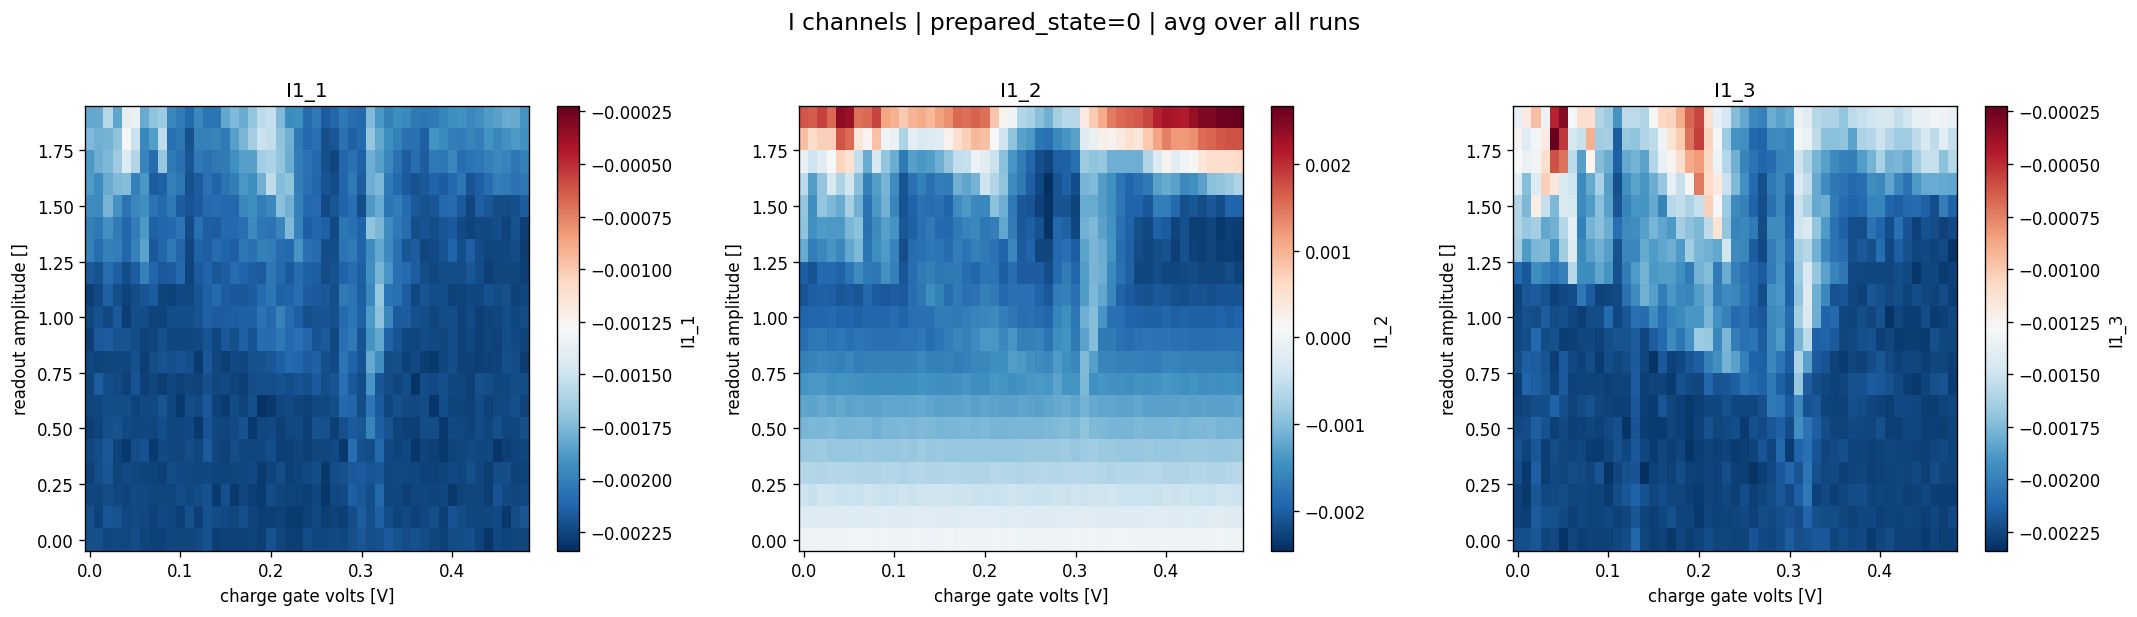

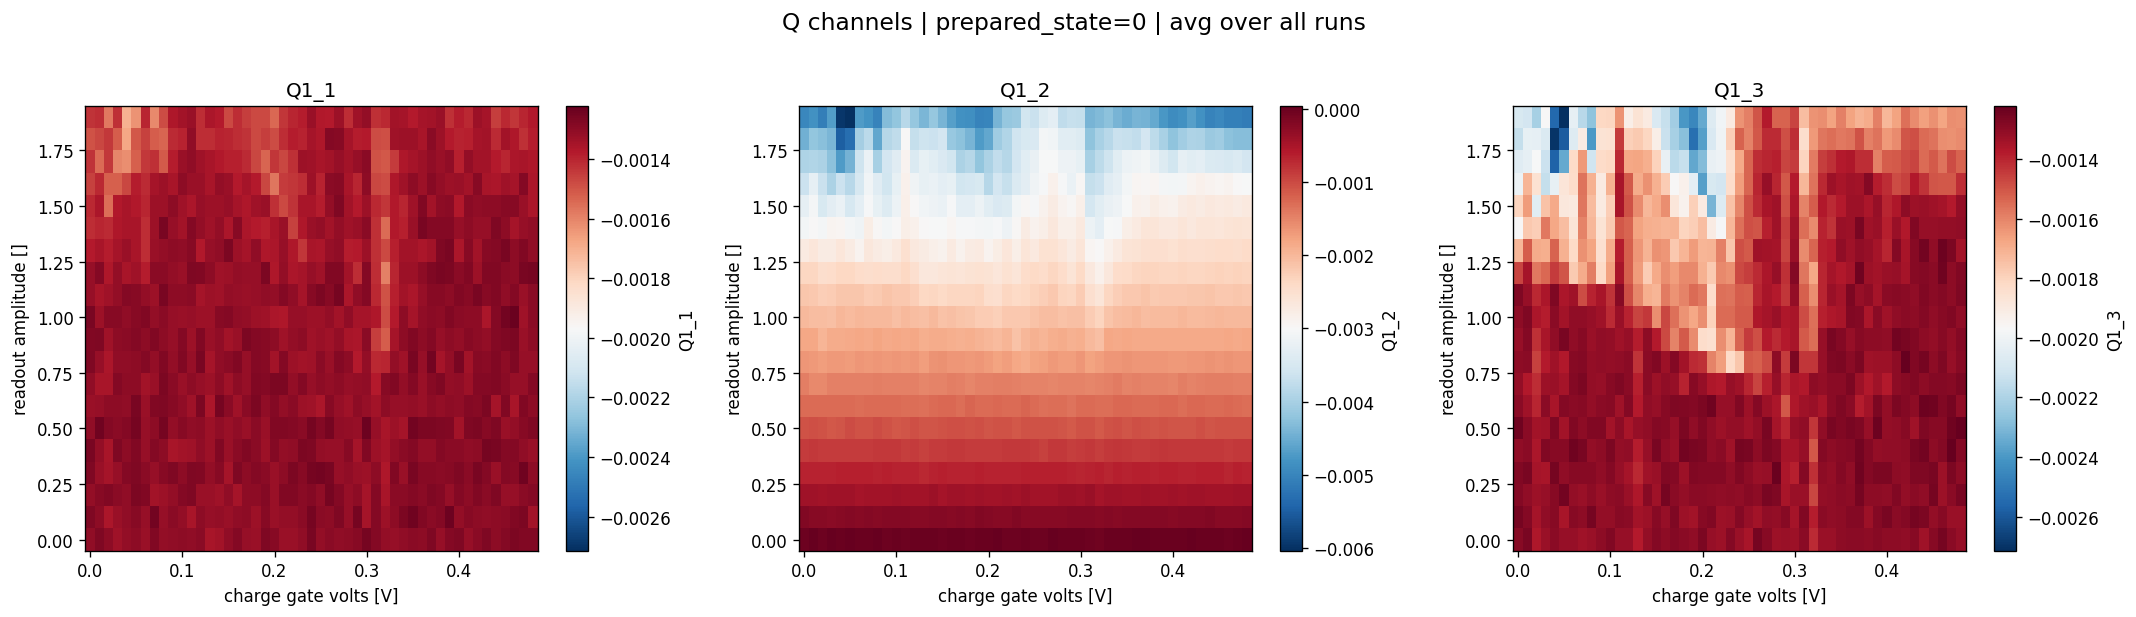

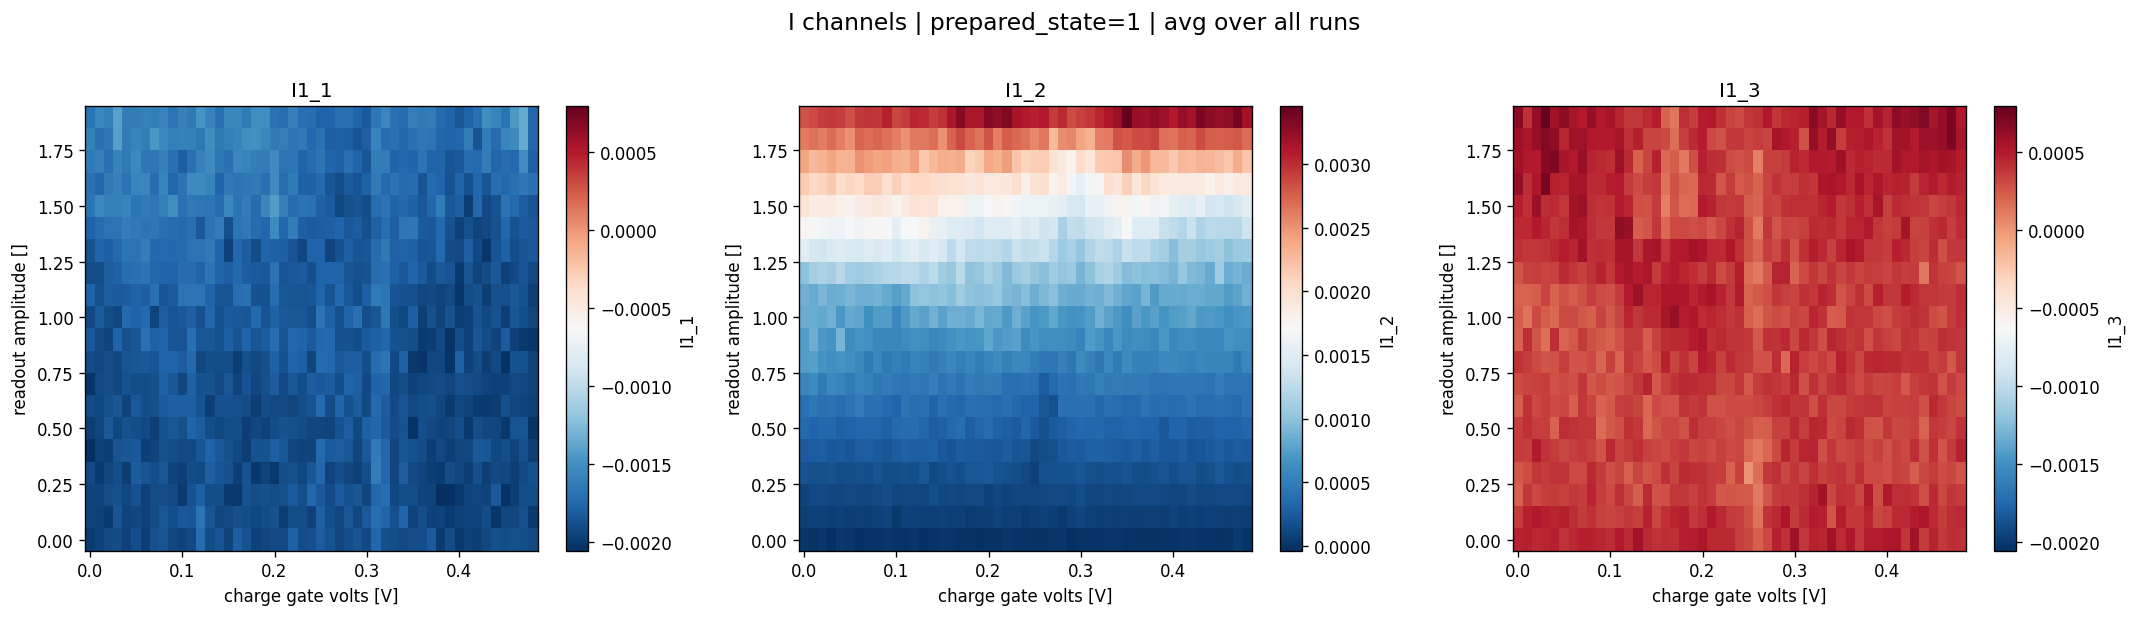

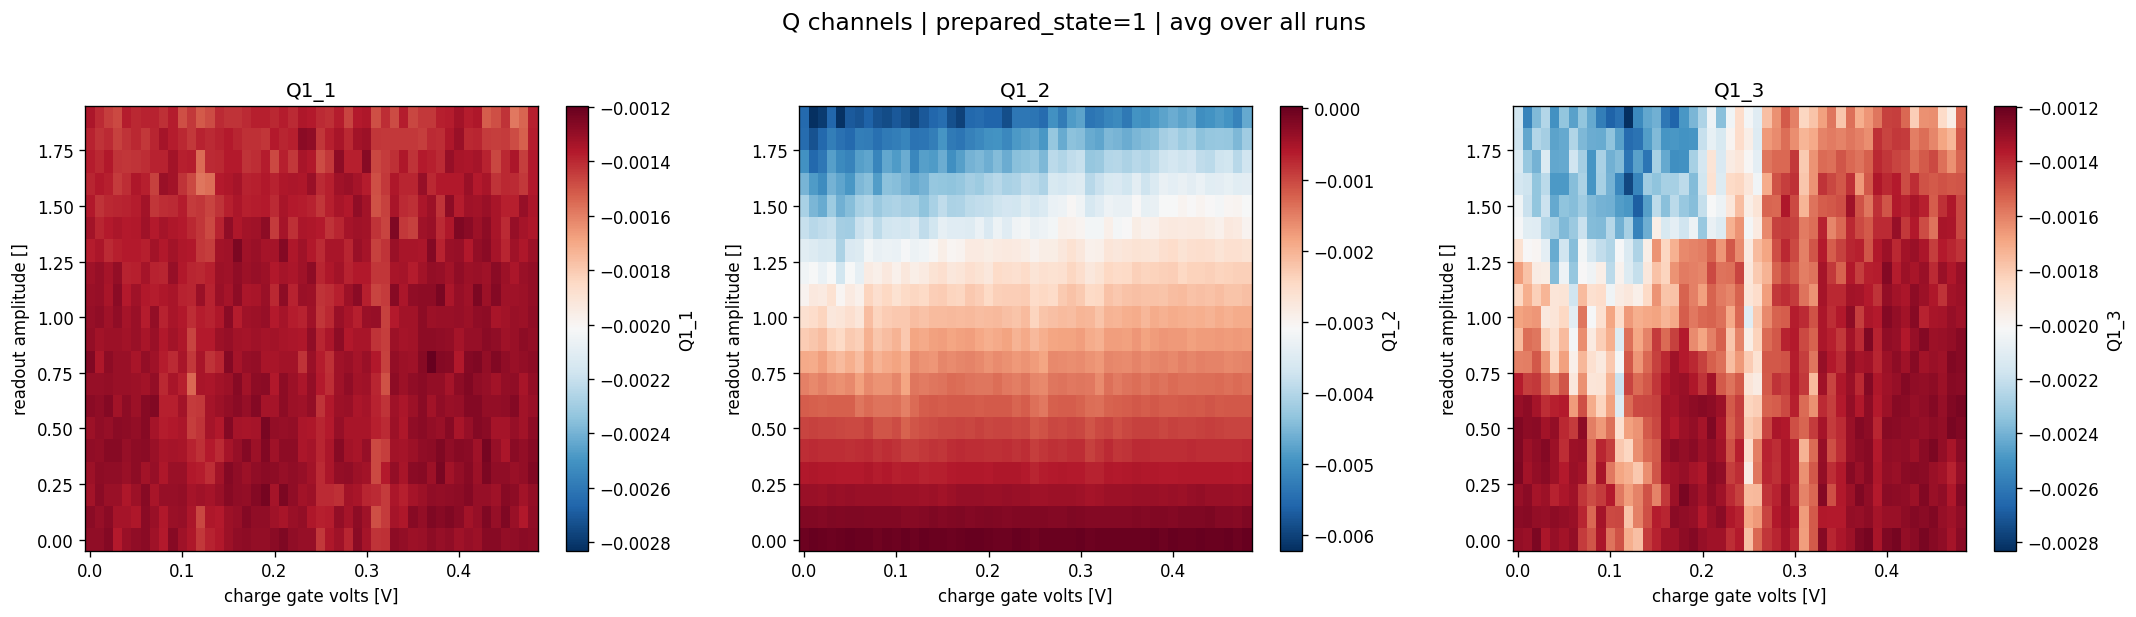

In [12]:
i_vars = ["I1_1", "I1_2", "I1_3"]
q_vars = ["Q1_1", "Q1_2", "Q1_3"]
prepared_states = ro_combined.coords["prepared_state"].values


# --- Averaged over all run_start ---
ro_avg = ro_combined.mean(dim="run_start")

for state in prepared_states:
    for group_label, group_vars in [("I", i_vars), ("Q", q_vars)]:
        means = [ro_avg[v].mean(dim="shot_idx").sel(prepared_state=state) for v in group_vars]

        shared_vmin = min(float(means[0].min()), float(means[2].min()))
        shared_vmax = max(float(means[0].max()), float(means[2].max()))

        n = len(group_vars)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), dpi=120, squeeze=False)
        for j, (var_name, mean_da) in enumerate(zip(group_vars, means)):
            if j in (0, 2):
                vmin, vmax = shared_vmin, shared_vmax
            else:
                vmin, vmax = float(mean_da.min()), float(mean_da.max())
            mean_da.plot.pcolormesh(
                ax=axes[0, j], x="charge_gate", y="amp_prefactor",
                cmap="RdBu_r", add_colorbar=True, vmin=vmin, vmax=vmax,
            )
            axes[0, j].set_title(var_name)
        fig.suptitle(
            f"{group_label} channels | prepared_state={state} | avg over all runs",
            fontsize=14, y=1.02,
        )
        plt.tight_layout()
        fig.savefig(os.path.join(FIGURE_SAVE_PATH,  f"ro_{group_label}_state{state}_avg.png"), dpi=150, bbox_inches="tight")
        plt.show()

---
# Part 3: Stable-Charge Filtered RO Data
Use the Ramsey `abscos_phase` to identify time intervals where the charge is stable,
then keep only the RO runs that fall within those intervals.

In [13]:
# --- Configuration ---
# Maximum allowed |abscos_phase[i+1] - abscos_phase[i]| to consider the interval stable
PHASE_THRESHOLD = 0.01  # in volts — adjust as needed

# Input files (already produced above; can also be loaded from disk)
RAMSEY_H5 = Ramsey_OUTPUT_H5        # charge_gate_ramsey_combined.h5
RO_H5     = RO_OUTPUT_H5     # ro_charge_power_combined.h5

# Output file for the filtered RO dataset
STABLE_OUTPUT_H5 = str(Path(DATA_ROOT) / "ro_charge_power_stable.h5")

In [14]:
# --- Identify stable intervals from Ramsey data ---
# ramsey_ds = combined_ds  # already in memory; or xr.open_dataset(RAMSEY_H5)
# ro_ds     = ro_combined  # already in memory; or xr.open_dataset(RO_H5)
with xr.open_dataset(RAMSEY_H5) as ds:
    ramsey_ds = ds.load()
with xr.open_dataset(RO_H5) as ds:
    ro_ds = ds.load()

ramsey_times = ramsey_ds.coords["run_start"].values
phases = ramsey_ds["abscos_phase"].values
freqs = ramsey_ds["abscos_frequency"].values

# |cos(2πf(x-φ))| is periodic in φ with period 1/(2f).
# Wrap phase differences to avoid false jumps when the fit returns
# a phase shifted by an integer number of half-periods.
freq_mid = np.nanmean(freqs)
half_period = 1.0 / (2.0 * freq_mid)

def wrapped_phase_delta(phi_a, phi_b, half_period):
    """Shortest-arc distance on the |cos| phase circle."""
    raw = abs(phi_b - phi_a) % half_period
    return min(raw, half_period - raw)

# Build list of (start, end) stable intervals
stable_intervals = []
for i in range(len(ramsey_times) - 1):
    delta = wrapped_phase_delta(phases[i], phases[i + 1], half_period)
    if delta < PHASE_THRESHOLD:
        stable_intervals.append((ramsey_times[i], ramsey_times[i + 1]))
        print(f"  Stable interval {len(stable_intervals)}: "
              f"{str(ramsey_times[i])[:19]} → {str(ramsey_times[i+1])[:19]}  "
              f"Δphase={delta:.4f}")

print(f"\nFound {len(stable_intervals)} stable intervals "
      f"(threshold={PHASE_THRESHOLD})")

# --- Filter RO run_starts that fall inside any stable interval ---
ro_times = ro_ds.coords["run_start"].values
keep_mask = np.zeros(len(ro_times), dtype=bool)

for j, t in enumerate(ro_times):
    for (t_lo, t_hi) in stable_intervals:
        if t_lo <= t <= t_hi:
            keep_mask[j] = True
            break

ro_stable = ro_ds.isel(run_start=keep_mask)
print(f"\nRO runs kept: {int(keep_mask.sum())} / {len(ro_times)}")
ro_stable

  Stable interval 1: 2026-04-14T10:38:42 → 2026-04-14T10:39:31  Δphase=0.0010
  Stable interval 2: 2026-04-14T10:39:31 → 2026-04-14T10:40:15  Δphase=0.0032
  Stable interval 3: 2026-04-14T10:40:15 → 2026-04-14T10:40:59  Δphase=0.0039
  Stable interval 4: 2026-04-14T10:40:59 → 2026-04-14T10:41:40  Δphase=0.0034
  Stable interval 5: 2026-04-14T10:41:40 → 2026-04-14T10:42:22  Δphase=0.0035
  Stable interval 6: 2026-04-14T10:42:22 → 2026-04-14T10:43:23  Δphase=0.0000
  Stable interval 7: 2026-04-14T10:44:06 → 2026-04-14T10:44:46  Δphase=0.0077
  Stable interval 8: 2026-04-14T10:45:34 → 2026-04-14T10:46:25  Δphase=0.0000
  Stable interval 9: 2026-04-14T10:46:25 → 2026-04-14T10:47:06  Δphase=0.0000
  Stable interval 10: 2026-04-14T10:47:58 → 2026-04-14T10:48:41  Δphase=0.0039
  Stable interval 11: 2026-04-14T10:48:41 → 2026-04-14T10:49:27  Δphase=0.0008
  Stable interval 12: 2026-04-14T10:50:06 → 2026-04-14T10:51:02  Δphase=0.0014
  Stable interval 13: 2026-04-14T10:52:45 → 2026-04-14T10:53:

<xarray.Dataset> Size: 34MB
Dimensions:         (run_start: 18, prepared_state: 2, charge_gate: 49,
                     amp_prefactor: 20, shot_idx: 20)
Coordinates:
  * run_start       (run_start) datetime64[ns] 144B 2026-04-14T10:38:53.13000...
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * shot_idx        (shot_idx) float64 160B 1.0 2.0 3.0 4.0 ... 18.0 19.0 20.0
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           object 8B 'q1'
Data variables:
    I1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_2            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_3            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_1            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_2            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_3            (run_start, prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    exp_time        (run_start) float64 144B 38.06 34.08 34.35 ... 32.33 30.67
Attributes:
    abscos_frequency_fixed:  0.59

period ≈ 1.695


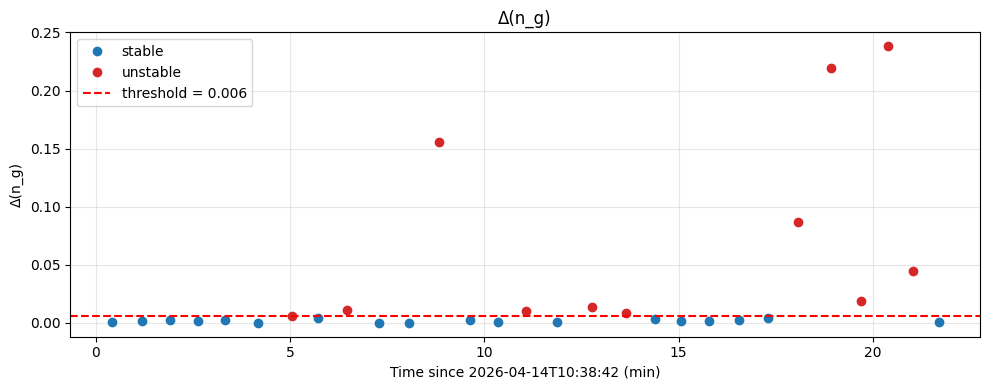

In [15]:
# Δphase between consecutive Ramsey runs vs relative time
ramsey_t_abs = ramsey_ds.coords["run_start"].values
ramsey_t_rel = (ramsey_t_abs - ramsey_t_abs[0]) / np.timedelta64(1, "m")

# Wrapped phase difference (accounts for |cos| periodicity)
delta_phase = np.array([
    wrapped_phase_delta(phases[i], phases[i + 1], half_period)
    for i in range(len(phases) - 1)
])

freq_mid = np.nanmean(freqs)
print(f"period ≈ {1/freq_mid:.3f}")
delta_phase_scaled = delta_phase * freq_mid
t_mid = (ramsey_t_rel[:-1] + ramsey_t_rel[1:]) / 2  # midpoint of each interval

stable_mask = delta_phase < PHASE_THRESHOLD

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_mid[stable_mask], delta_phase_scaled[stable_mask], "o", color="C0", label="stable")
ax.plot(t_mid[~stable_mask], delta_phase_scaled[~stable_mask], "o", color="C3", label="unstable")
ax.axhline(PHASE_THRESHOLD * freq_mid, color="r", ls="--",
           label=f"threshold = {(PHASE_THRESHOLD*freq_mid):.3f}")

ax.set_xlabel(f"Time since {str(ramsey_t_abs[0])[:19]} (min)")
ax.set_ylabel("Δ(n_g)")
ax.set_title("Δ(n_g)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"stable_ng.png"), dpi=150, bbox_inches="tight")

plt.show()

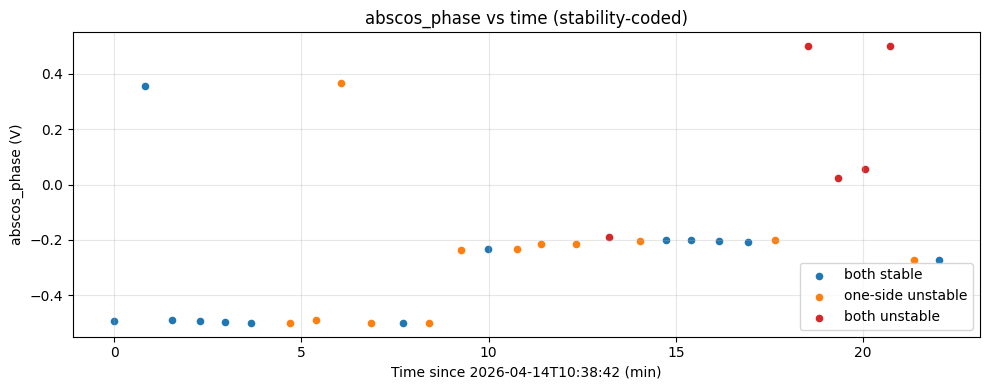

In [16]:
# Phase vs time, color-coded by stability of neighbouring intervals
# Blue: both neighbours stable, Orange: one unstable, Red: both unstable

n_pts = len(phases)
colors = []
for i in range(n_pts):
    before_stable = stable_mask[i - 1] if i > 0 else True
    after_stable  = stable_mask[i]     if i < n_pts - 1 else True
    if before_stable and after_stable:
        colors.append("C0")   # blue
    elif before_stable or after_stable:
        colors.append("C1")   # orange
    else:
        colors.append("C3")   # red

fig, ax = plt.subplots(figsize=(10, 4))
for c, label in [("C0", "both stable"), ("C1", "one-side unstable"), ("C3", "both unstable")]:
    mask = [cl == c for cl in colors]
    if any(mask):
        ax.scatter(ramsey_t_rel[mask], phases[mask], c=c, label=label, s=20)

ax.set_xlabel(f"Time since {str(ramsey_t_abs[0])[:19]} (min)")
ax.set_ylabel("abscos_phase (V)")
ax.set_title("abscos_phase vs time (stability-coded)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Save Filtered Dataset

In [17]:
ro_stable.to_netcdf(STABLE_OUTPUT_H5, engine="h5netcdf")
print(f"Saved stable-filtered RO results to:\n  {STABLE_OUTPUT_H5}")

Saved stable-filtered RO results to:
  D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\2DMAP\square_AR_test\ro_charge_power_stable.h5


## Quick Plots — Stable-Filtered Average

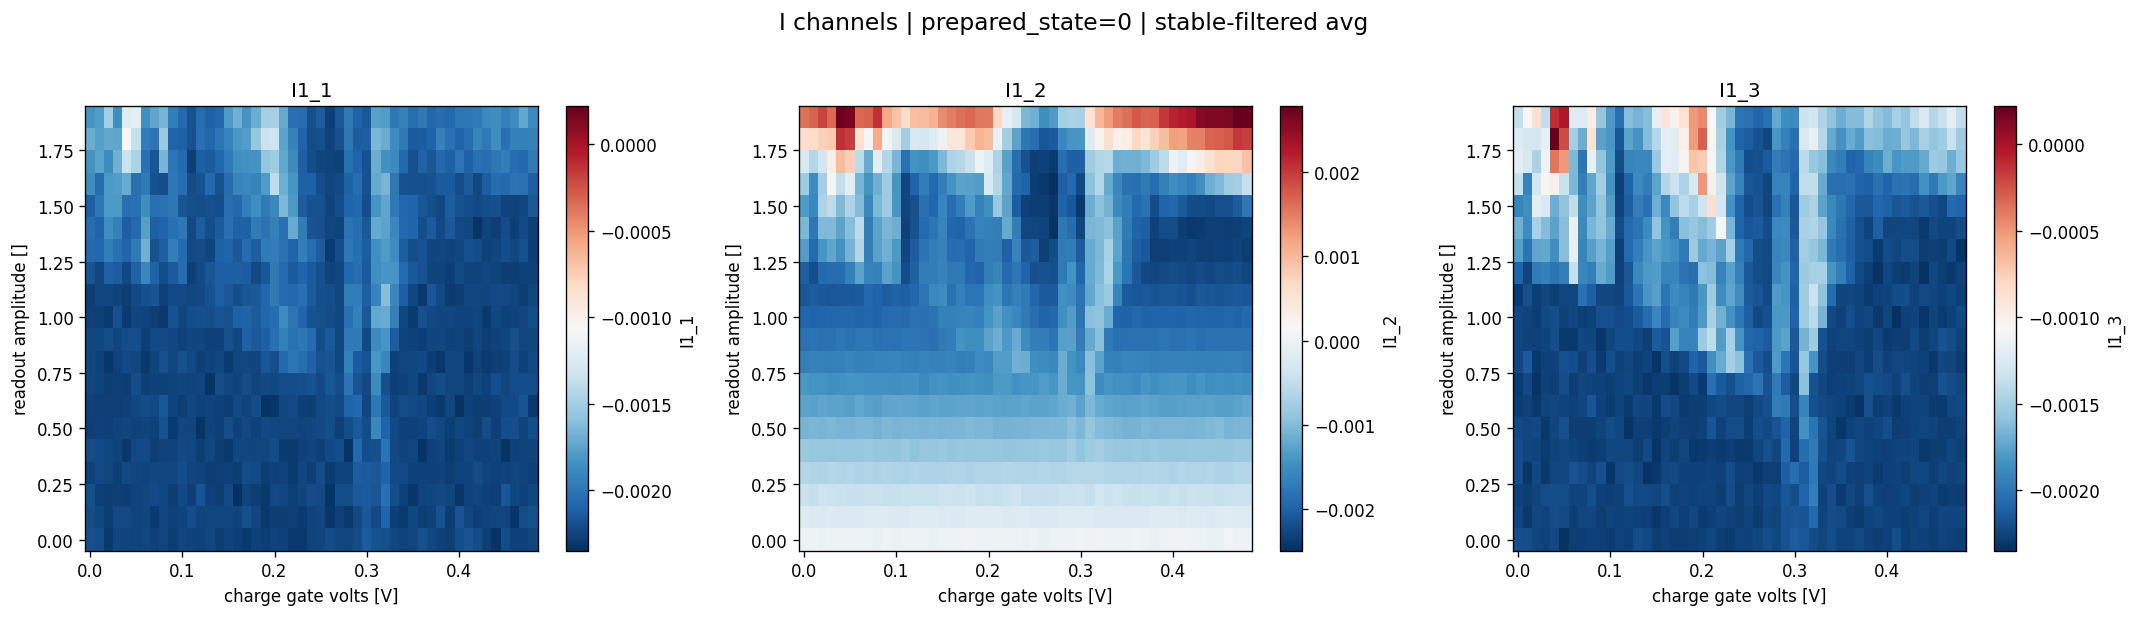

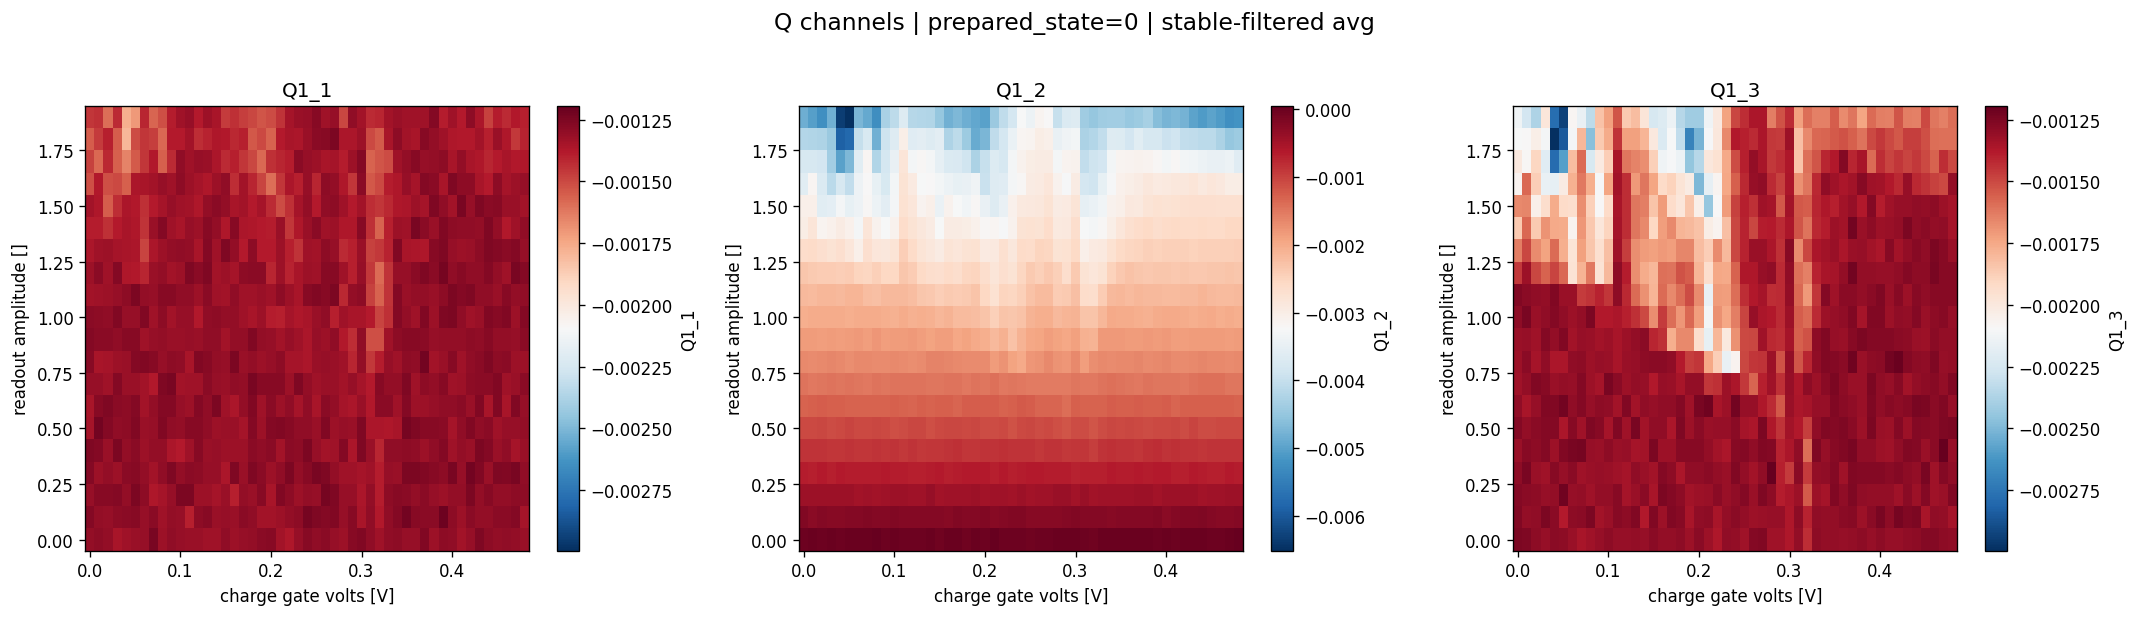

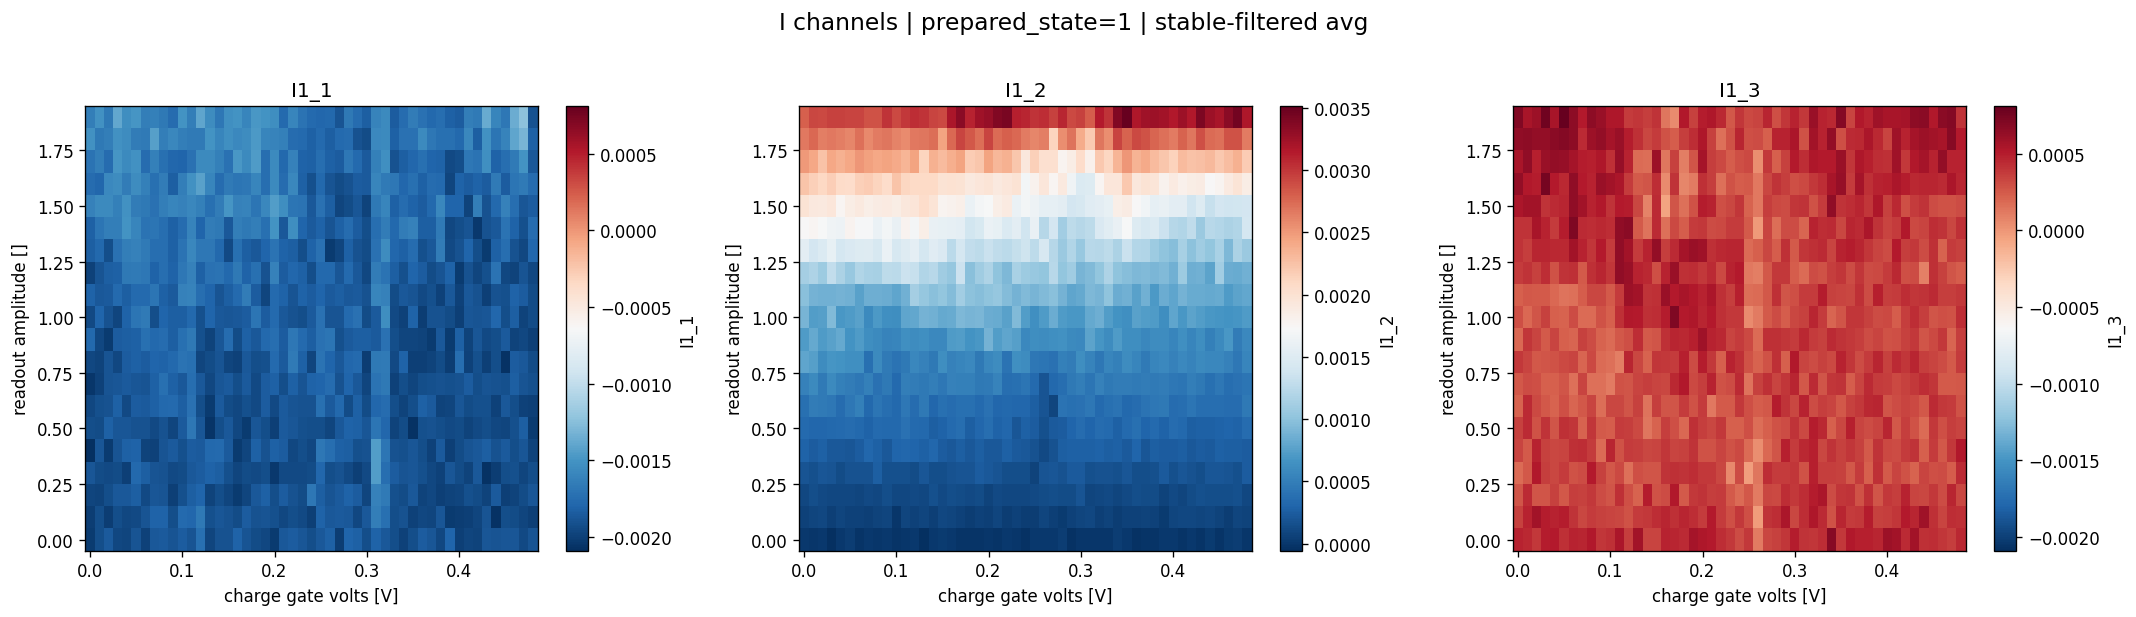

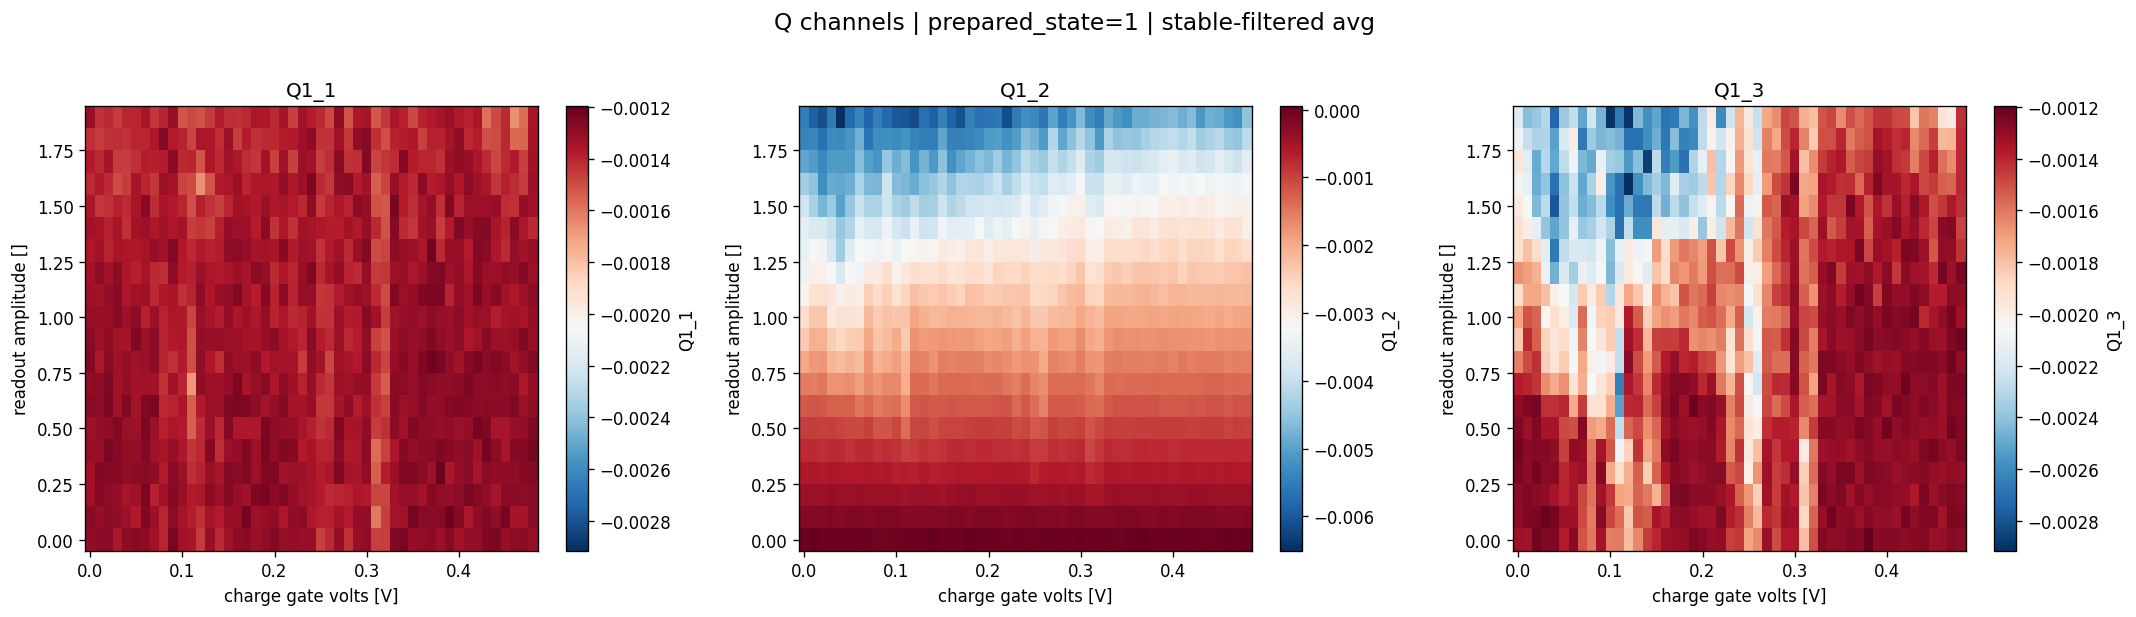

In [18]:
i_vars = ["I1_1", "I1_2", "I1_3"]
q_vars = ["Q1_1", "Q1_2", "Q1_3"]
prepared_states = ro_stable.coords["prepared_state"].values


ro_stable_avg = ro_stable.mean(dim="run_start")

for state in prepared_states:
    for group_label, group_vars in [("I", i_vars), ("Q", q_vars)]:
        means = [ro_stable_avg[v].mean(dim="shot_idx").sel(prepared_state=state) for v in group_vars]

        shared_vmin = min(float(means[0].min()), float(means[2].min()))
        shared_vmax = max(float(means[0].max()), float(means[2].max()))

        n = len(group_vars)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), dpi=120, squeeze=False)
        for j, (var_name, mean_da) in enumerate(zip(group_vars, means)):
            if j in (0, 2):
                vmin, vmax = shared_vmin, shared_vmax
            else:
                vmin, vmax = float(mean_da.min()), float(mean_da.max())
            mean_da.plot.pcolormesh(
                ax=axes[0, j], x="charge_gate", y="amp_prefactor",
                cmap="RdBu_r", add_colorbar=True, vmin=vmin, vmax=vmax,
            )
            axes[0, j].set_title(var_name)
        fig.suptitle(
            f"{group_label} channels | prepared_state={state} | stable-filtered avg",
            fontsize=14, y=1.02,
        )
        plt.tight_layout()
        fig.savefig(os.path.join(FIGURE_SAVE_PATH, f"ro_{group_label}_state{state}_filtered_avg.png"), dpi=150, bbox_inches="tight")
        plt.show()

In [19]:
# Stack shot_idx across all stable run_starts → single long shot_idx dimension
# Result dims: (prepared_state, charge_gate, amp_prefactor, shot_idx)
ro_merged = (
    ro_stable[RO_SIGNAL_VARS]
    .stack(merged_shot=("run_start", "shot_idx"))
    .reset_index("merged_shot", drop=True)
    .rename({"merged_shot": "shot_idx"})
)
print(ro_merged)

MERGED_OUTPUT_H5 = str(Path(DATA_ROOT) / "ro_charge_power_stable_merged.h5")

# Release any stale HDF5 file handles held by xarray's cache
import gc
gc.collect()
if os.path.exists(MERGED_OUTPUT_H5):
    os.remove(MERGED_OUTPUT_H5)

ro_merged.to_netcdf(MERGED_OUTPUT_H5, engine="h5netcdf", mode="w")
print(f"\nSaved merged stable RO dataset to:\n  {MERGED_OUTPUT_H5}")

<xarray.Dataset> Size: 34MB
Dimensions:         (prepared_state: 2, charge_gate: 49, amp_prefactor: 20,
                     shot_idx: 360)
Coordinates:
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           object 8B 'q1'
Dimensions without coordinates: shot_idx
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ..